# TC 5033
## Deep Learning
## Convolutional Neural Networks

### Team 21: 

* Juan Pablo Carvajal Acosta ------ A01796843
* Luis Manuel Velasco Iglesias ---- A00226599
* Mayra Hernández Alba ------------ A01796828
* Sergio David Jardon Avalos ------ A01688787

### Activity 2b: Building a CNN for CIFAR10 dataset with PyTorch


- Objective

    The main goal of this activity is to further your understanding of Convolutional Neural Networks (CNNs) by building one using PyTorch. You will apply this architecture to the famous CIFAR10 dataset, taking what you've learned from the guide code that replicated the Fully Connected model in PyTorch (Activity 2a).

- Instructions
    This activity requires submission in teams of 5 or 6 members. Submissions from smaller or larger teams will not be accepted unless prior approval has been granted (only due to exceptional circumstances). While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Understand the Guide Code: Review the guide code from Activity 2a that implemented a Fully Connected model in PyTorch. Note how PyTorch makes it easier to implement neural networks.

    Familiarize Yourself with CNNs: Take some time to understand their architecture and the rationale behind using convolutional layers.

    Prepare the Dataset: Use PyTorch's DataLoader to manage the dataset. Make sure the data is appropriately preprocessed for a CNN.

    Design the CNN Architecture: Create a new architecture that incorporates convolutional layers. Use PyTorch modules like nn.Conv2d, nn.MaxPool2d, and others to build your network.

    Training Loop and Backpropagation: Implement the training loop, leveraging PyTorch’s autograd for backpropagation. Keep track of relevant performance metrics.

    Analyze and Document: Use Markdown cells to explain your architectural decisions, performance results, and any challenges you faced. Compare this model with your previous Fully Connected model in terms of performance and efficiency.

- Evaluation Criteria

    - Understanding of CNN architecture and its application to the CIFAR10 dataset
    - Code Readability and Comments
    - Appropriateness and efficiency of the chosen CNN architecture
    - Correct implementation of Traning Loop and Accuracy Function
    - Model's performance metrics on the CIFAR10 dataset (at least 65% accuracy)
    - Quality of Markdown documentation

- Submission

Submit via Canvas your Jupyter Notebook with the CNN implemented in PyTorch. Your submission should include well-commented code and Markdown cells that provide a comprehensive view of your design decisions, performance metrics, and learnings.

In [46]:
# importing libraries

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt


In [47]:
# check if GPU is available and set device 

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cuda


## Loading and Preprocessing CIFAR-10

We download and load the CIFAR-10 dataset using PyTorch's built-in datasets. The images are normalized using mean=[0.491, 0.482, 0.447] and std=[0.247, 0.243, 0.261] computed from the training set.

**Data splits:**
- Training: 50,000 images
- Validation: 5,000 images  
- Test: 5,000 images

### Download Cifar10 dataset

In [48]:
# Download and prepare the CIFAR-10 dataset

DATA_PATH = './Databases/cifar-10-batches-py'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, len(cifar10_test))))

In [49]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./Databases/cifar-10-batches-py
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

In [50]:
train_loader.batch_size

64

In [51]:
for i, (x,y) in enumerate(test_loader):
    print(i, x.shape, y.shape)

0 torch.Size([64, 3, 32, 32]) torch.Size([64])
1 torch.Size([64, 3, 32, 32]) torch.Size([64])
2 torch.Size([64, 3, 32, 32]) torch.Size([64])
3 torch.Size([64, 3, 32, 32]) torch.Size([64])
4 torch.Size([64, 3, 32, 32]) torch.Size([64])
5 torch.Size([64, 3, 32, 32]) torch.Size([64])
6 torch.Size([64, 3, 32, 32]) torch.Size([64])
7 torch.Size([64, 3, 32, 32]) torch.Size([64])
8 torch.Size([64, 3, 32, 32]) torch.Size([64])
9 torch.Size([64, 3, 32, 32]) torch.Size([64])
10 torch.Size([64, 3, 32, 32]) torch.Size([64])
11 torch.Size([64, 3, 32, 32]) torch.Size([64])
12 torch.Size([64, 3, 32, 32]) torch.Size([64])
13 torch.Size([64, 3, 32, 32]) torch.Size([64])
14 torch.Size([64, 3, 32, 32]) torch.Size([64])
15 torch.Size([64, 3, 32, 32]) torch.Size([64])
16 torch.Size([64, 3, 32, 32]) torch.Size([64])
17 torch.Size([64, 3, 32, 32]) torch.Size([64])
18 torch.Size([64, 3, 32, 32]) torch.Size([64])
19 torch.Size([64, 3, 32, 32]) torch.Size([64])
20 torch.Size([64, 3, 32, 32]) torch.Size([64])
21

## Showing Images

Below we visualize sample images from each class to understand the dataset characteristics. CIFAR-10 images are only 32×32 pixels, making them challenging to classify.

The image repesents a: frog


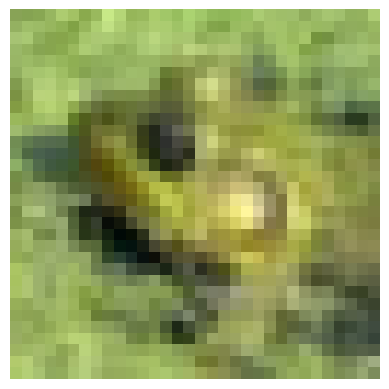

In [52]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'The image repesents a: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


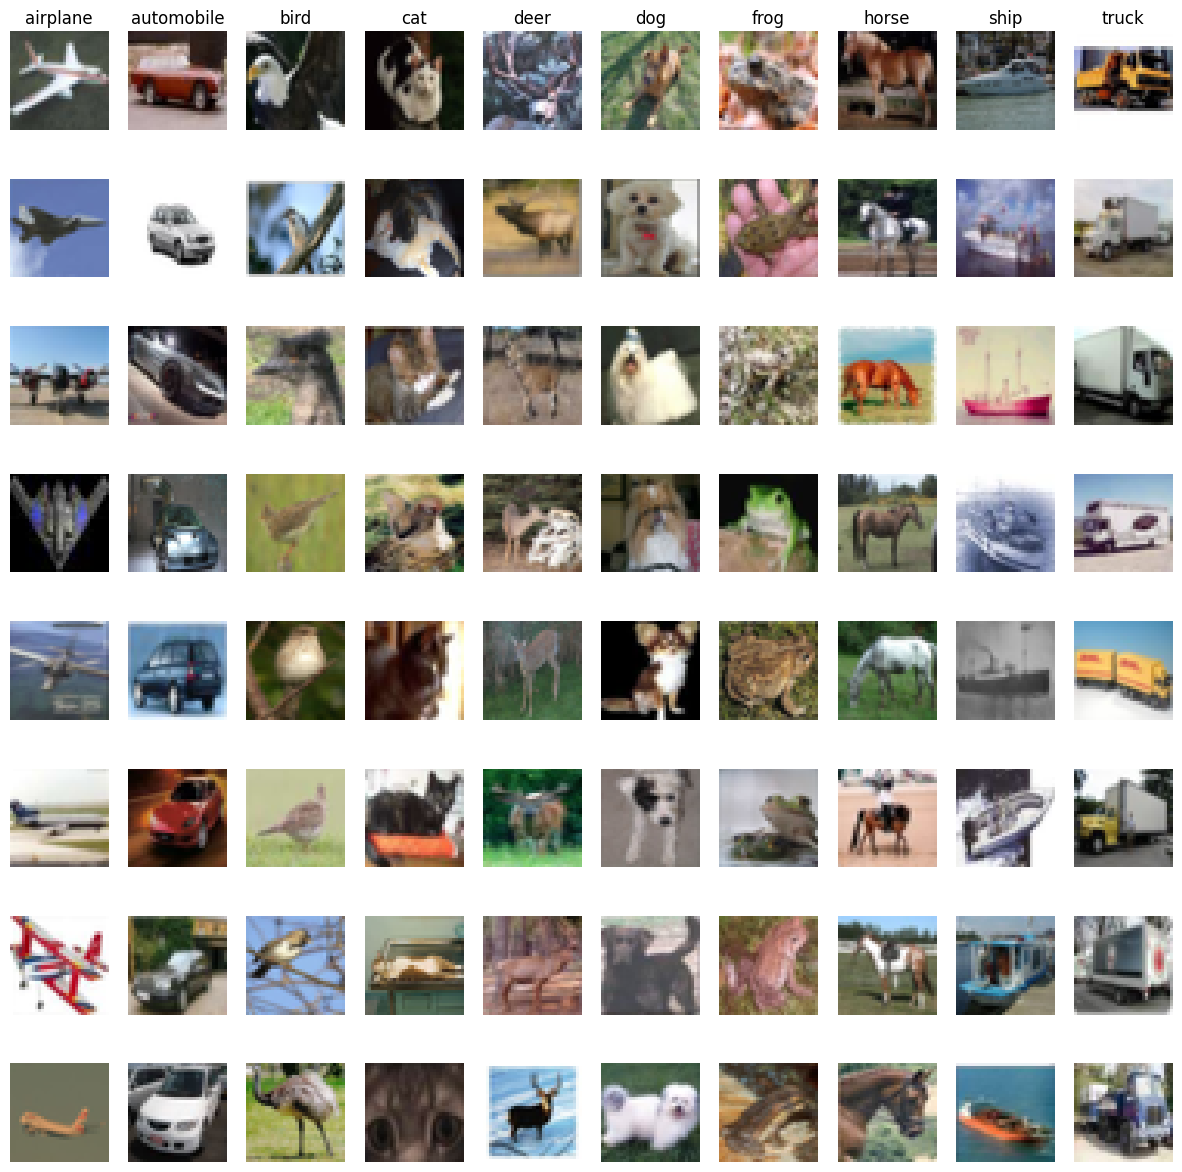

In [53]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')
            
            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid() 

## Accuracy Evaluation Function


This function calculates classification accuracy by comparing model predictions to true labels. It uses `model.eval()` to disable dropout and sets `torch.no_grad()` to save memory during inference.

**How it works:**
1. Iterate through all batches in the data loader
2. Get model predictions (argmax of output scores)
3. Count correct predictions
4. Return accuracy as a percentage (0-1)

In [54]:
def accuracy(model, loader):

    # keep track of correct predictions and total examples
    num_correct = 0
    num_total = 0

    # put model in evaluation mode (disables dropout, batch‑norm updates, etc.)
    model.eval()

    # ensure model is on the right device before running
    model = model.to(device=device)

    with torch.no_grad():                    # no grad needed for inference
        for xi, yi in loader:                # iterate over batches from the loader
            
            # move inputs and labels to gpu
            xi = xi.to(device=device, dtype=torch.float32)   
            yi = yi.to(device=device, dtype=torch.long) 

            scores = model(xi)               # forward pass, calculates class scores for xi
            _, pred = scores.max(dim=1)      # predicted class is index of max score
            
            num_correct += (pred == yi).sum()    # count correct in this batch
            num_total += pred.size(0)            # add batch size to total
            
        return float(num_correct) / num_total     # return overall accuracy

## Training Loop Implementation

The training loop implements the standard deep learning workflow:

**Training process per epoch:**
1. **Forward pass**: Compute model predictions
2. **Loss calculation**: Use cross-entropy loss (appropriate for multi-class classification)
3. **Backward pass**: Compute gradients via backpropagation
4. **Optimization**: Update weights using Adam optimizer
5. **Validation**: Evaluate accuracy on validation set


**Why Adam optimizer?**

Adam adapts the learning rate for each parameter, converging faster than standard SGD while requiring minimal hyperparameter tuning

In [55]:
def train(model, optimiser, epochs=100):
    
    # send the model to the selected device (GPU/CPU)
    model = model.to(device=device)

    # Initialize lists to store metrics
    train_losses = []
    val_accuracies = []

    for epoch in range(epochs): # epoch loop
        
         # set model to training mode 
        model.train()  

        # reset running totals at start of each epoch
        epoch_loss = 0      # sum of batch losses for this epoch
        num_batches = 0     # count of processed minibatches

        # iterate over minibatches from the training loader
        for i, (xi, yi) in enumerate(train_loader):


            # move inputs/labels to device and enforce correct dtype
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)

            scores = model(xi)                                  # forward pass
            
            cost = F.cross_entropy(input=scores, target=yi)     # compute loss
            
            optimiser.zero_grad()           # clear previous gradients
            cost.backward()                 # backpropagate the error
            optimiser.step()                # update the parameters


            # add this batch's loss (scalar) to the epoch total
            epoch_loss += cost.item()
            # count that we've processed one more minibatch
            num_batches += 1
       
       
        
        # compute average loss for this epoch and store it
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        # after each epoch, evaluate on the validation set
        acc = accuracy(model, val_loader)

        # store validation accuracy for this epoch
        val_accuracies.append(acc)


        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')


    return train_losses, val_accuracies

In [56]:

def plot_metrics(losses, accs, model_name):
    """
    Plot training loss and validation accuracy for one model
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Training Loss
    axes[0].plot(losses, marker='o', linewidth=2, color='#1f77b4')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Training Loss', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Validation Accuracy
    axes[1].plot(accs, marker='o', linewidth=2, color='#ff7f0e')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()


## Linear Model

In [57]:
hidden1 = 512
hidden = 256
lr = 0.001
epochs = 10

In [58]:

model1 = nn.Sequential(nn.Flatten(),
                       nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
                       nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=10))
optimiser1 = torch.optim.Adam(model1.parameters(), lr=lr)

In [59]:
print("------ Training Linear Model -----------")
linear_losses, linear_acc = train(model1, optimiser1, epochs)

------ Training Linear Model -----------
Epoch: 0, costo: 2.068061351776123, accuracy: 0.4658,
Epoch: 1, costo: 1.2909348011016846, accuracy: 0.4868,
Epoch: 2, costo: 1.465528964996338, accuracy: 0.503,
Epoch: 3, costo: 1.0538127422332764, accuracy: 0.4994,
Epoch: 4, costo: 1.180406093597412, accuracy: 0.5154,
Epoch: 5, costo: 1.5100078582763672, accuracy: 0.525,
Epoch: 6, costo: 0.8160431981086731, accuracy: 0.5388,
Epoch: 7, costo: 0.9173142910003662, accuracy: 0.5274,
Epoch: 8, costo: 1.2690200805664062, accuracy: 0.5228,
Epoch: 9, costo: 0.839012622833252, accuracy: 0.5342,


In [60]:
print("Linear test acc:", accuracy(model1, test_loader))

Linear test acc: 0.5196


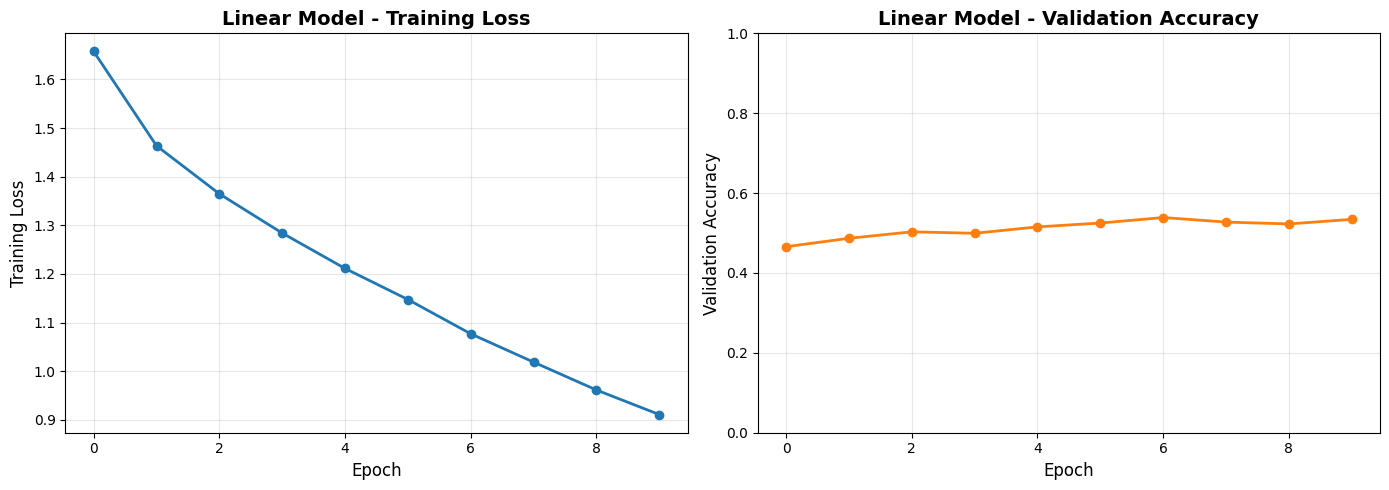

In [61]:
plot_metrics(linear_losses, linear_acc, "Linear Model")

### Linear Model Analysis

The fully connected baseline achieves **51.36% test accuracy** on CIFAR-10. This is only slightly better than random guessing (10% for 10 classes), showing that a simple linear model struggles with image classification.

**Why it performs poorly:**
- No spatial awareness – treats pixels as independent features
- Cannot detect edges, textures, or patterns
- Flattening 32×32×3 images loses spatial structure


## Convolutional Neural Network (CNN)


Our CNN uses **2 CNNclass blocks**, each containing 2 convolutional layers with BatchNorm.

### Architecture

| Block | Layers | Output Shape | Purpose |
|-------|--------|--------------|---------|
| 1 | Conv(3→16) + BN + ReLU<br>Conv(16→32) + BN + ReLU<br>MaxPool(2×2) | 32×16×16 | Extract low-level features (edges, colors) |
| 2 | Conv(32→128) + BN + ReLU<br>Conv(128→128) + BN + ReLU<br>MaxPool(2×2) | 128×8×8 | Extract high-level features (object parts) |
| Classifier | Flatten<br>Linear(8,192→256) + ReLU<br>Linear(256→10) | 10 | Combine features and map to class scores |

### Key Design Choices

- **BatchNorm**: Normalizes activations after each conv, accelerating training and acting as regularization
- **Two convs per block**: Increases receptive field and feature complexity before downsampling
- **Padding=1, Kernel=3**: Preserves spatial dimensions during convolution (output size = input size)
- **MaxPool(2×2)**: Reduces dimensions by half after extracting features
- **Progressive channels** (3→16→32→128→128): Captures increasingly abstract features at deeper layers
- **Final flatten + FC layers**: Maps 128×8×8 = 8,192 features to 10 class scores


In [62]:
# lambda function to create a convolutional layer with kernel size 3 and padding 1
conv_k_3 = lambda channel1, channel2: nn.Conv2d(channel1, channel2, kernel_size=3, padding=1)

In [63]:
# Define a CNN class with two convolutional layers, batch‑norm, and max‑poolings

# This will be the basic block we will stack to build our CNN model

class CNN_class(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        # first convolution + batch‑norm block
        # conv_k_3 is a lambda defined earlier giving Conv2d(kernel_size=3,padding=1)
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1)

        # second convolution + batch‑norm block
        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2)
        
        # max‑pool layer to reduce spatial dimensions by factor of 2
        self.max_pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        # apply first conv -> batch‑norm -> relu
        x = F.relu(self.bn1(self.conv1(x)))
        # then second conv -> batch‑norm -> relu
        x = F.relu(self.bn2(self.conv2(x)))
        # finally downsample with max‑pool and return
        return self.max_pool(x)

In [64]:
channel1 = 16
channel2 = 32
channel3 = 64
channel4 = 128
epochs = 20
lr = 0.001


In [65]:

# build a small CNN by stacking two CNN_class blocks and then a final linear classifier

# build a small CNN by stacking two CNN_class blocks and then a final linear classifier

modelCNN1 = nn.Sequential(
            # first block takes 3‑channel input (RGB) and produces channel1 feature maps, then channel2 maps after second conv
            CNN_class(3, channel1, channel2),

            # second block ups the channels further: input comes from previous block’s channel2 maps, end up with channel4 maps
            CNN_class(channel2, channel4, channel4),

            # flatten the 4×4 spatial maps (after two max‑pools) into a vector so we can feed it to a linear layer
            nn.Flatten(),

            # Fully connected classifier 
            # at this point the tensor has shape (batch, 128, 8, 8) → 8*8*128 = 8192 features
            nn.Linear(8*8*128, 256),  # project the pooled conv features down to 256 dims
            nn.ReLU(),
            nn.Dropout(0.5),          # optional regularisation to reduce over‑fitting
            nn.Linear(256, 10)        # final FC layer mapping to the 10 class scores
            )

# create an Adam optimizer for the parameters of modelCNN1
# using the learning rate already defined in `lr`
optimisercnn = torch.optim.Adam(modelCNN1.parameters(), lr)

In [66]:
print("------ Training CNN Model -----------")
cnn_losses, cnn_accs = train(modelCNN1, optimisercnn, epochs)

------ Training CNN Model -----------
Epoch: 0, costo: 1.3534877300262451, accuracy: 0.553,
Epoch: 1, costo: 1.19840407371521, accuracy: 0.6492,
Epoch: 2, costo: 0.6994144916534424, accuracy: 0.7162,
Epoch: 3, costo: 1.2849394083023071, accuracy: 0.7026,
Epoch: 4, costo: 0.883653998374939, accuracy: 0.7198,
Epoch: 5, costo: 1.114338755607605, accuracy: 0.7688,
Epoch: 6, costo: 0.838083028793335, accuracy: 0.772,
Epoch: 7, costo: 1.0352997779846191, accuracy: 0.7614,
Epoch: 8, costo: 0.35450083017349243, accuracy: 0.8012,
Epoch: 9, costo: 0.9112032651901245, accuracy: 0.7936,
Epoch: 10, costo: 1.1984155178070068, accuracy: 0.7932,
Epoch: 11, costo: 0.9005979895591736, accuracy: 0.7686,
Epoch: 12, costo: 0.5588725209236145, accuracy: 0.8128,
Epoch: 13, costo: 0.19286349415779114, accuracy: 0.8062,
Epoch: 14, costo: 0.205934077501297, accuracy: 0.816,
Epoch: 15, costo: 0.19205504655838013, accuracy: 0.8068,
Epoch: 16, costo: 0.38478875160217285, accuracy: 0.8146,
Epoch: 17, costo: 0.29733

In [67]:
accuracy(modelCNN1, test_loader)

0.8124

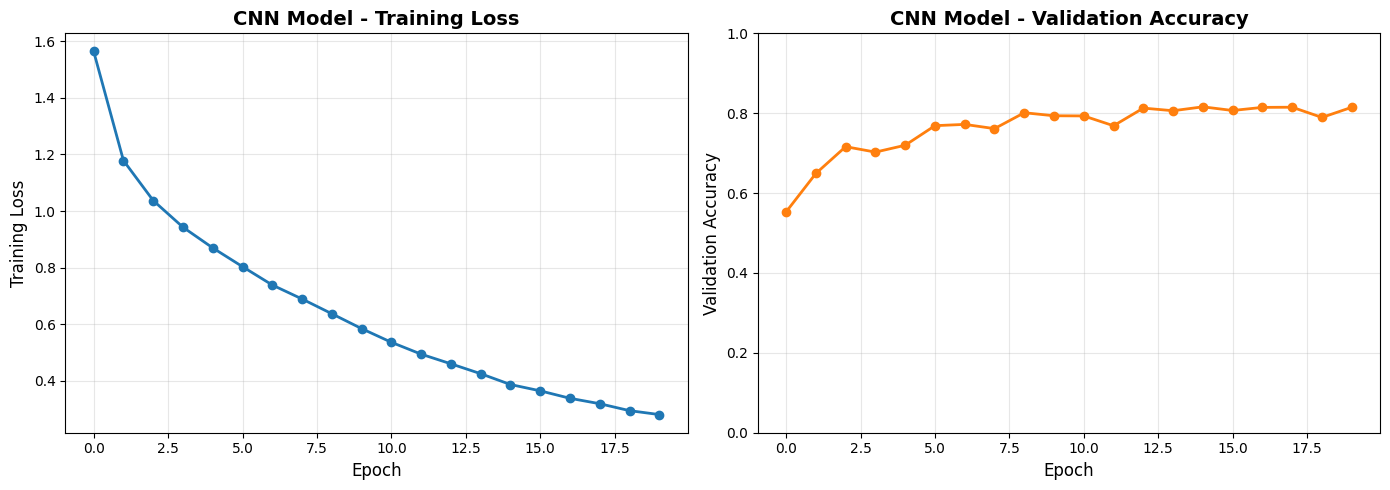

In [68]:
plot_metrics(cnn_losses, cnn_accs, "CNN Model")

## CNN vs Linear Model Comparison

| Model | Architecture | Test Accuracy | Improvement |
|-------|--------------|---------------|-------------|
| Linear (Baseline) | FC(3072→512→256→10) | 51.96% | - |
| CNN | 2 CNNclass blocks + BatchNorm + FC | 81.24% | +29.28% |

**Why CNN performs better:**
1. **Spatial awareness** – Convolutional layers preserve 2D structure of images, unlike flattened FC layers
2. **Feature hierarchy** – Learns edges → textures → object parts automatically through stacked layers
3. **Parameter efficiency** – Shared convolutional weights (e.g., 3×3 kernel) drastically reduce parameters vs. dense connections, reducing overfitting
4. **Translation invariance** – MaxPooling makes the model robust to small shifts/translations in objects

**Result:** The CNN **exceeded the 65% accuracy requirement** (achieving **81%**), demonstrating that convolutional architectures with BatchNorm are essential for image classification tasks. The model successfully learned hierarchical features and achieved strong generalization on unseen test data.
